![Amazon Sales Analysis](https://upload.wikimedia.org/wikipedia/commons/a/a9/Amazon_logo.svg)

In [140]:
import pandas as pd
import numpy as np

In [141]:
df = pd.read_csv('/content/cleaned_data (6).csv')

In [142]:
df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [143]:
df.shape

(10000, 26)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Order_Date        10000 non-null  object 
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  object 
 5   Season            10000 non-null  object 
 6   Customer_ID       10000 non-null  object 
 7   Customer_Gender   10000 non-null  object 
 8   Customer_Segment  10000 non-null  object 
 9   Region            10000 non-null  object 
 10  Country           10000 non-null  object 
 11  Category          10000 non-null  object 
 12  Sub_Category      10000 non-null  object 
 13  Product_Name      10000 non-null  object 
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64

In [145]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Year,0
Month,0
Quarter,0
Season,0
Customer_ID,0
Customer_Gender,0
Customer_Segment,0
Region,0


In [146]:
duplicates_count = df.duplicated().sum()
print("Number of duplicates ", duplicates_count)

Number of duplicates  0


In [147]:

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [148]:
print( df['Order_Date'].dtype)

datetime64[ns]


In [149]:

df['year'] = df['Order_Date'].dt.year
df['month'] = df['Order_Date'].dt.strftime('%b')
df['day_name'] = df['Order_Date'].dt.day_name()

df[['Order_Date', 'year', 'month', 'day_name']].head(3)

,Order_Date,year,month,day_name
0,2023-01-18,2023,Jan,Wednesday
1,2023-11-13,2023,Nov,Monday
2,2022-04-28,2022,Apr,Thursday


In [150]:
df.groupby('Category')[['Revenue', 'Quantity']].sum().sort_values(by='Revenue', ascending=False)

,Revenue,Quantity
Category,,
Electronics,3382028.46,5287
Home & Kitchen,892842.02,5535
Clothing,407471.79,5375
Books & Media,386644.46,5667
Beauty & Health,215400.97,5449


In [151]:
df.groupby('Region')[['Profit', 'Discount']].mean().sort_values(by='Profit', ascending=False)

,Profit,Discount
Region,,
Middle East,156.437286,0.171928
North America,140.936749,0.173962
Asia,140.502598,0.179832
Europe,137.360818,0.181419


In [152]:
df.groupby(['year', 'month'])[['Revenue', 'Profit']].sum()

Revenue    Profit
year month                     
2021 Apr     27697.60   4227.08
     Aug     77747.37  23982.27
     Dec     71681.84  21099.63
     Feb      8321.14   2310.85
     Jan      9276.43   3967.15
     Jul     32789.34   9524.55
     Jun     30822.00   7524.44
     Mar      7377.79   1914.07
     May     30890.90   7687.58
     Nov     90212.85  27944.62
     Oct     76343.18  23840.24
     Sep     42899.92  14508.57
2022 Apr     90843.32  22018.56
     Aug    135158.20  44521.67
     Dec    173355.96  45594.42
     Feb     80586.86  25010.16
     Jan     99447.76  26306.70
     Jul     96608.36  25869.85
     Jun     84819.58  22044.72
     Mar     81247.66  21556.13
     May    104394.77  21380.97
     Nov    118006.26  32686.05
     Oct    144532.12  34391.04
     Sep    112844.16  34724.30
2023 Apr    212100.12  54505.47
     Aug    208638.33  56801.47
     Dec    159644.80  44627.07
     Feb    137356.66  35107.99
     Jan    160492.14  45116.04
     Jul    194852.38  61185.23
     Jun    185774.37  48969.35
     Mar    197306.40  49695.94
     May    167834.38  52011.40
     Nov    214531.59  59282.12
     Oct    243996.98  62925.36
     Sep    226111.87  55048.68
2024 Apr    115816.69  28829.47
     Aug     58527.17  12260.95
     Dec      5898.51    210.99
     Feb    130107.66  38105.19
     Jan    216708.74  58740.93
     Jul     87216.46  28818.34
     Jun     97892.55  25222.85
     Mar    200513.46  54705.51
     May    145646.96  37434.72
     Nov     11455.41   2147.20
     Oct     36398.51  12467.32
     Sep     41660.19   8783.10

In [153]:
df.groupby('Category')[['Profit_Margin_%', 'Cost']].agg({'Profit_Margin_%': 'mean', 'Cost': 'sum'}).sort_values(by='Profit_Margin_%', ascending=False)

,Profit_Margin_%,Cost
Category,,
Clothing,24.803338,291766.50
Books & Media,23.611307,281606.77
Beauty & Health,23.477439,156375.24
Electronics,23.344370,2456580.31
Home & Kitchen,23.019188,660420.57


In [154]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season',
       'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%',
       'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method',
       'Order_Status', 'year', 'month', 'day_name'],
      dtype='object')


In [155]:
df['Revenue'].corr(df['Discount'])

np.float64(-0.08633160922463463)

In [156]:
df['Revenue'].corr(df['Profit_Margin_%'])

np.float64(0.07571775097248566)

In [157]:
df['Revenue'].corr(df['Unit_Price'])

np.float64(0.7385655839379411)

In [158]:
df['Discount'].corr(df['Profit'])

np.float64(-0.2540756228285077)

In [159]:
df['Discount'].corr(df['Quantity'])

np.float64(0.001707650049063155)

In [160]:
df['Profit_Margin_%'].corr(df['Cost'])

np.float64(-0.037661983927343386)

In [161]:
df['Profit_Margin_%'].corr(df['Cost'])

np.float64(-0.037661983927343386)

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import  plotly.graph_objects as go
import plotly.figure_factory as ff



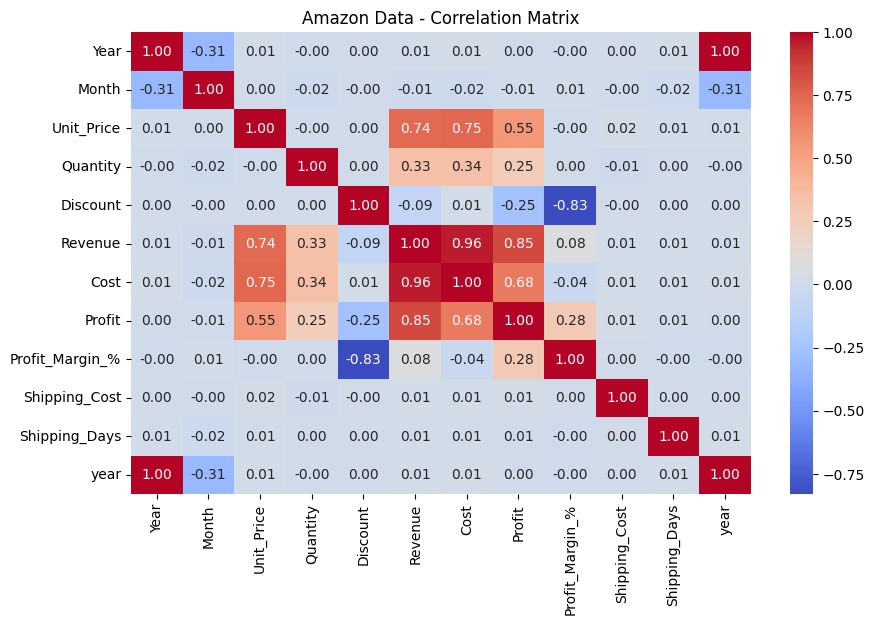

In [163]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Amazon Data - Correlation Matrix')
plt.show()

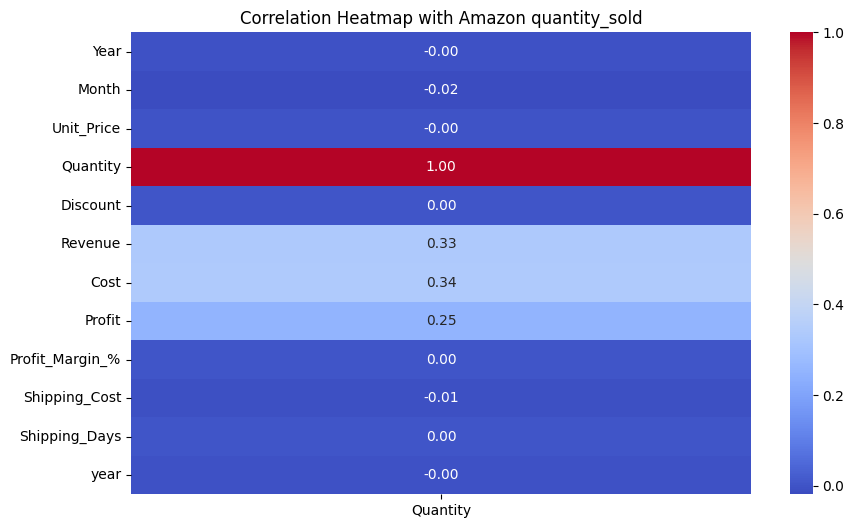

In [164]:
corr = df.corr(numeric_only=True)[['Quantity']]
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap with Amazon quantity_sold')
plt.show()

In [165]:
df_plot = df.groupby('Order_Date')['Revenue'].sum().reset_index().sort_values('Order_Date')

fig = px.line(df_plot, x='Order_Date', y='Revenue', title='Total Revenue Over Time')
fig.update_xaxes(title_text='Order Date')
fig.update_yaxes(title_text='Total Revenue ($)')
fig.show()

In [166]:
df_plot = df.groupby('Category')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=True)

fig = px.bar(df_plot, x='Revenue', y='Category', orientation='h', title='Total Revenue by Product Category')
fig.update_xaxes(title_text='Total Revenue ($)')
fig.update_yaxes(title_text='Product Category')
fig.show()

In [167]:
df_plot = df.groupby('Region')['Profit'].sum().reset_index().sort_values('Profit', ascending=False)

fig = px.bar(df_plot, x='Region', y='Profit', title='Total Profit by Customer Region')
fig.update_xaxes(title_text='Customer Region')
fig.update_yaxes(title_text='Total Profit ($)')
fig.show()

In [168]:
df_plot = df['Payment_Method'].value_counts().reset_index()
df_plot.columns = ['payment_method', 'Cost']

fig = px.pie(df_plot, names='payment_method', values='Cost', title='Payment Methods Distribution')
fig.show()

In [169]:
df_plot = df.groupby('Category')['Profit_Margin_%'].mean().reset_index().sort_values('Profit_Margin_%', ascending=False)

fig = px.bar(df_plot, x='Category', y='Profit_Margin_%', title='Average Customer Rating by Category')
fig.update_xaxes(title_text='Product Category')
fig.update_yaxes(title_text='Average Rating (Out of 5)')
fig.show()

In [170]:
df_plot = df.groupby('month')['Revenue'].sum().reset_index()

fig = px.bar(df_plot, x='month', y='Revenue', title='Total Revenue by Month')
fig.update_xaxes(title_text='Month')
fig.update_yaxes(title_text='Total Revenue ($)')
fig.show()

In [171]:
df_plot = df.groupby('Discount')['Quantity'].sum().reset_index()

fig = px.scatter(df_plot, x='Discount', y='Quantity', title='Impact of Discount Percent on Quantity Sold')
fig.update_xaxes(title_text='Discount Percent (%)')
fig.update_yaxes(title_text='Total Quantity Sold')
fig.show()

In [172]:
df_plot = df.groupby(['year', 'Region'])['Profit'].sum().reset_index()

fig = px.bar(df_plot, x='year', y='Profit', color='Region', barmode='group', title='Yearly Profit by Customer Region')
fig.update_xaxes(title_text='Year')
fig.update_yaxes(title_text='Total Profit ($)')
fig.show()

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


In [174]:
features = ['Unit_Price', 'Discount', 'Discount', 'Quantity', 'Profit_Margin_%', 'Cost']
X = df[features]
y = df['Revenue']

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)


In [176]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [177]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R2 Score: {r2:.4f}")
print(f"Model RMSE: {rmse:.2f}")

Model R2 Score: 0.9770
Model RMSE: 150.80


In [178]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(mae)
print(mse)
print(rmse)
print(r2)

93.17667893268974
22741.715721864413
150.80356667487814
0.9769779492959145


In [179]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [180]:
fig = px.scatter(
    results,
    x='Actual',
    y='Predicted',
    title='Actual vs Predicted Weekly Sales',
    labels={
        'Actual': 'Actual Weekly Sales',
        'Predicted': 'Predicted Weekly Sales'
    },
    opacity=0.6
)
min_value = min(results['Actual'].min(), results['Predicted'].min())
max_value = max(results['Actual'].max(), results['Predicted'].max())
fig.add_shape(
    type='line',
    x0=min_value,
    y0=min_value,
    x1=max_value,
    y1=max_value,
    line=dict(dash='dash')
)

fig.show()